In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Definindo médias e desvios padrão para as notas nas duas estratégias
media_estrategia_A = 70
desvio_padrao_estrategia_A = 10

media_estrategia_B = 75
desvio_padrao_estrategia_B = 12

# Gerando as amostras de notas para cada estratégia de ensino da nossa base
np.random.seed(0)  # Para garantir a reprodutibilidade dos resultados
amostra_estrategia_A = np.random.normal(loc=media_estrategia_A, scale=desvio_padrao_estrategia_A, size=50)
amostra_estrategia_B = np.random.normal(loc=media_estrategia_B, scale=desvio_padrao_estrategia_B, size=50)

print("Notas da Estratégia A:", amostra_estrategia_A[:5])
print("Notas da Estratégia B:", amostra_estrategia_B[:5])

Notas da Estratégia A: [87.64052346 74.00157208 79.78737984 92.40893199 88.6755799 ]
Notas da Estratégia B: [64.25440127 79.64282997 68.87033835 60.83241379 74.66181326]


In [ ]:
# 1) De acordo com as informações analisadas o nosso teste é unilateral á direita, esquerda ou bicaudal? Justifique.

In [4]:
# teste unilateral à direita, pois:
# H0 - A média das notas dos alunos na estratégia A é igual à média das notas dos alunos na estratégia B. Isso significa que não há diferença 
# significativa entre as duas estratégias.
# H1 - A média das notas na Estratégia B é maior do que a média das notas na Estratégia A. Isso significa que você está interessado em verificar se a 
# Estratégia B resulta em notas significativamente maiores do que a Estratégia A.
# Como a hipótese alternativa especifica que a média da Estratégia B é maior que a média da Estratégia A, a região crítica do teste estará 
# localizada na cauda direita da distribuição da estatística de teste.

In [5]:
# 2) Calcule as médias para as duas amostragens e as variâncias. Quais insights você pode retirar comparando os dados?

In [6]:
# Cálculo das médias
media_estrategia_A = np.mean(amostra_estrategia_A)
media_estrategia_B = np.mean(amostra_estrategia_B)

# Cálculo das variâncias
variancia_estrategia_A = np.var(amostra_estrategia_A)
variancia_estrategia_B = np.var(amostra_estrategia_B)

# Impressão dos resultados
print("Média da Estratégia A:", media_estrategia_A)
print("Variância da Estratégia A:", variancia_estrategia_A)

print("Média da Estratégia B:", media_estrategia_B)
print("Variância da Estratégia B:", variancia_estrategia_B)

Média da Estratégia A: 71.40559272313098
Variância da Estratégia A: 126.68018446943104
Média da Estratégia B: 74.74868110507046
Variância da Estratégia B: 108.26062024217782


In [7]:
# A média da Estratégia B é ligeiramente maior do que a média da Estratégia A. Isto sugere que a Estratégia B pode ter um impacto 
# ligeiramente positivo no desempenho dos alunos em comparação com a Estratégia A.

# A variância da Estratégia A é maior do que a variância da Estratégia B. Isto indica que as notas dos alunos na Estratégia A têm uma maior 
# dispersão em relação à média do que as notas na Estratégia B.

In [15]:
# Desvios padrão das amostras
std_A = np.std(amostra_estrategia_A, ddof=1)
std_B = np.std(amostra_estrategia_B, ddof=1)

# Tamanhos das amostras
n_A = len(amostra_estrategia_A)
n_B = len(amostra_estrategia_B)

# Erro padrão da diferença entre as médias
SE = np.sqrt((variancia_estrategia_A / n_A) + (variancia_estrategia_B / n_B))

# Estatística de teste Z
z_stat = (media_estrategia_B - media_estrategia_A) / SE

# P Value (teste unilateral à direita)
p_value = 1 - stats.norm.cdf(z_stat)

# Imprimir resultados
print("Estatística de teste Z:", z_stat)
print("P Value:", p_value)

Estatística de teste Z: 1.542245935902539
P Value: 0.06150692063904584


In [12]:
# 3) Imprima os resultados da estatística do teste Z, p value e indique se rejeitaremos ou não a hipótese nula. Justifique sua resposta.

In [13]:
# Como P Value é de 0.06 e o valor de alpha é de 0.05, concluimos que P Value > alpha, sendo assim, nosso projeto não possui o valor minimo aceitavel 
# de 95% de confianca. sendo assim, nao descartaremos a hipotese nula

In [16]:
# 4) Para finalizar monte o gráfico da distribuição da estatística do nosso teste Z e explique o que pode ser observado através dele.

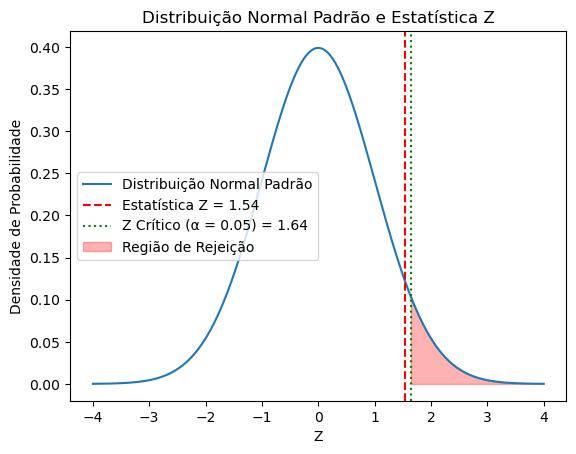

In [22]:
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

# alpha = 0.05

plt.plot(x, y, label='Distribuição Normal Padrão')
plt.axvline(z_stat, color='red', linestyle='--', label=f'Estatística Z = {z_stat:.2f}')
plt.axvline(stats.norm.ppf(1 - 0.05), color='green', linestyle=':', label=f'Z Crítico (α = {0.05}) = {stats.norm.ppf(1 - 0.05):.2f}')

# Preencher a região de rejeição
x_fill = np.linspace(stats.norm.ppf(1 - 0.05), 4, 100)
y_fill = stats.norm.pdf(x_fill, 0, 1)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.3, label='Região de Rejeição')

plt.title('Distribuição Normal Padrão e Estatística Z')
plt.xlabel('Z')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.show()

In [23]:
# O gráfico comprova que nao podemos rejeitar a hipotese nula, pois o valor observado esta antes da area de significancia e do Z critico